> ### Public copy (demo data)
>
> The client's 2024 survey cannot be shared publicly, so it is **not in this repository**. Instead,
> `scripts/make_demo_workbook.py` creates `data/raw/engagement_survey_2024.xlsx`, a stand-in file
> with the same structure as the real one: the same sheet name, 22 columns, 42 rows, category
> headers, two 1-10 items and the same delta-from-company-mean format. Only the numbers are
> **invented**.
>
> This means the code, the method and the reasoning below are the originals, but every number,
> table and chart comes from demo data. Phase 1 figures are labelled **DEMO** instead of REAL.
> Where a result depends on the client's numbers, the text says what to look for instead of
> quoting them. Everything the notebooks produce is written to `outputs/`.
>
> To run on the real data, put the client workbook in `data/raw/` and set `data.provenance` to
> `real` in `config/config.yaml`. The labels then switch back.
 

# 06 — Phase 3: Putting the two phases side by side

|  |  |
|---|---|
| **Purpose** | Set what Phase 1 could answer against what Phase 2 unlocked, and turn the gap between them into the 2026 instrument and a priority map. |
| **Input** | Phase 1 survey results + Phase 2 demonstration results |
| **Outputs** | `tab20`–`tab23` · `fig09` |
| **Objectives** | RO4 — the refined objectives are defined in the README |

> **Claim boundary.** The two axes of this notebook come from different places. **Performance**
> comes from the survey workbook (Phase 1). **Importance** comes from the synthetic demonstration
> (Phase 2). They are combined to set priorities, never to state new facts about a workforce. In
> this public copy the performance side is computed from the demo workbook.

In [1]:
# Environment setup
import sys
sys.path.insert(0, "../src")

import warnings
warnings.filterwarnings("ignore", message=".*encountered in matmul.*",
                        category=RuntimeWarning)  # spurious BLAS warning; see NB03

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from engagement import io, quality, phase1, models, synthesis, viz
from engagement.config import load_config

cfg = load_config()
pd.set_option("display.max_colwidth", 110)

---
## A. What each phase could answer

**Decision box**

| | |
|---|---|
| **What** | One row per client question: what Phase 1 could do, what Phase 2 added, and the exact missing data element that explains the difference. |
| **Why it is computed, not written** | This table is the evidence every 2026 recommendation points back to. Building it from the results keeps it from drifting out of step with them, and it is stated once instead of repeated in each notebook. |
| **Feeds** | `tab20` |

In [2]:
comparison = synthesis.capability_comparison()
comparison

,Phase 1 (real 2024 data),Phase 2 (synthetic demonstration),missing data element -> 2026
client question,,,
What drives engagement? (O2),"Prohibited: aggregated means, no outcome variable","Ranked, VIF-checked, triangulated driver table (tab16)",Individual responses + UWES outcome block
Who is at risk? (O3),"Department-level screening only (9 items flagged, tab06)","Individual risk scores, temporally validated, explainable (tab17-18)",Individual responses + demographics
Are the scales sound?,Untestable (no item-level data); scale-mixing defect found (tab01),Alpha per construct; short-scale weakness exposed (tab15),Item-level responses
Are there segments? (O1/O3),"No archetypes recoverable (silhouette < 0.25, NB03)",Persona machinery with risk & demographic profiles (tab19),Demographics + department sizes
Is engagement moving? (O1),Single 2024 snapshot,Wave trajectories (fig08),"Multi-wave collection, comparable instrument"


**Read:** read the third column first. Every gap between the two phases traces to a **missing
data element**, not to a weak method.

That is what makes the 2026 recommendation a consequence rather than a preference. Nothing here
says "we would have liked better data". Each row names the field that was absent and the analysis
that became possible once it existed.

---
## B. Importance against performance: where to act

**Decision box**

| | |
|---|---|
| **What** | Phase 2 driver importance (relative weights, `tab16`) against Phase 1 performance (corrected theme means, `tab03`), with each theme's weakest item plotted next to its mean. |
| **Why plot the weakest item too** | A theme mean averages a whole block. A theme can sit comfortably above the midpoint while its weakest question sits well below its own mean, and that question is what an intervention would target. |
| **Why the panel is split** | The constructs the 2024 survey never measured have no performance value at all, so they cannot be placed on the 2×2. That absence is the headline, so they are shown separately rather than dropped. |
| **Feeds** | `tab21`, `fig09` |

In [3]:
# recompute the two inputs from source (same functions the pipeline uses)
tidy = io.tidy(io.load_heatmap(cfg), cfg)
harmonised = quality.harmonise_scales(quality.reconstruct_absolute(tidy), cfg)
theme_means = phase1.theme_ranking(harmonised)["mean"]

data = pd.read_csv("../data/synthetic/synthetic_panel.csv")
item_map = pd.read_csv("../data/synthetic/synthetic_item_map.csv", index_col=0)
model_df = models.prepare(data, item_map, cfg)
drivers = models.driver_analysis(model_df[model_df["wave"] == 1])

ip = synthesis.importance_performance(drivers, theme_means,
                                      phase1.dispersion_screen(harmonised, cfg))

a = ip.attrs
print(f"importance measured by the 2024 survey : "
      f"{ip.loc[ip['measured_2024'], 'importance_%'].sum():.1f}%")
print(f"importance NOT measured in 2024        : "
      f"{ip.loc[~ip['measured_2024'], 'importance_%'].sum():.1f}%")
print(f"importance/performance rank alignment  : rho = {a['rank_alignment_spearman']}")
print(f"IMPROVE cell empty by construction     : {a['improve_cell_empty_by_construction']}")
print(f"performance axis span                  : {a['performance_span']} of a scale point")
print(f"priority items inside PROTECT themes   : "
      f"{int(ip.loc[ip['quadrant'].str.startswith('PROTECT'), 'n_priority_items'].sum())} of 9")

ip

importance measured by the 2024 survey : 55.4%
importance NOT measured in 2024        : 44.6%
importance/performance rank alignment  : rho = 0.8
IMPROVE cell empty by construction     : True
performance axis span                  : 0.797 of a scale point
priority items inside PROTECT themes   : 1 of 9


,importance_%,performance_2024,measured_2024,n_priority_items,weakest_item_score,weakest_item,quadrant
construct,,,,,,,
development,24.1,3.823,True,0.0,3.65,I believe I have an equal opportunity within the team to have a stable,"PROTECT (high importance, high performance)"
personal,23.8,NaN,False,NaN,NaN,,MEASURE FIRST (not in 2024 survey)
social,21.0,3.965,True,1.0,3.60,I feel comfortable sharing my ideas at work with peers and management.,"PROTECT (high importance, high performance)"
psych_safety,9.0,NaN,False,NaN,NaN,,MEASURE FIRST (not in 2024 survey)
technology,7.8,NaN,False,NaN,NaN,,MEASURE FIRST (not in 2024 survey)
balance,6.2,3.640,True,2.0,3.43,I feel the amount of work assigned to me is manageable,"MONITOR (low importance, low performance)"
justice,4.1,3.168,True,6.0,3.05,I trust the Executive team to lead the business to success.,"MONITOR (low importance, low performance)"
esg,4.0,NaN,False,NaN,NaN,,MEASURE FIRST (not in 2024 survey)


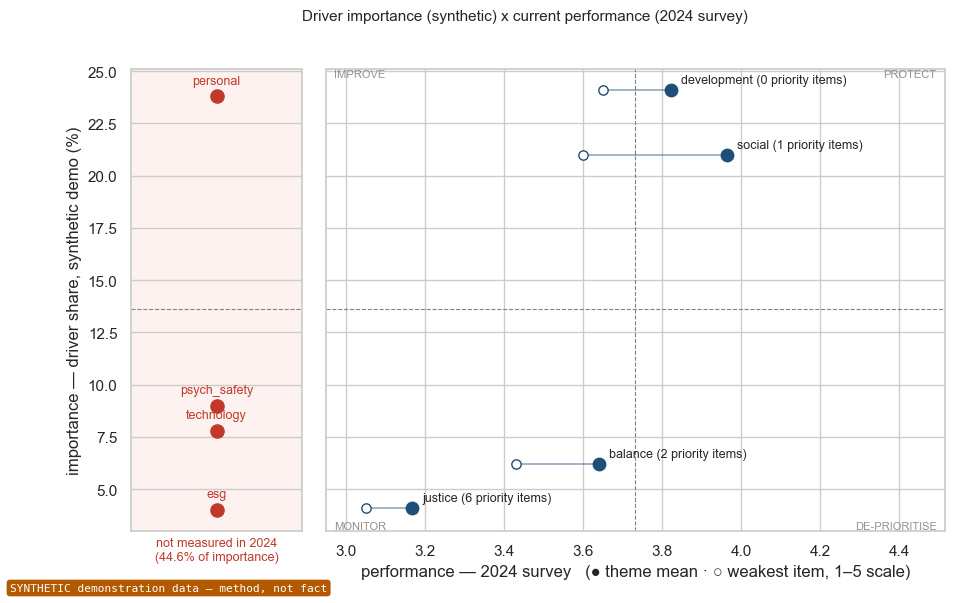

In [4]:
m = ip[ip["measured_2024"]].copy()
u = ip[~ip["measured_2024"]].copy()
imp_med, perf_med = m["importance_%"].median(), m["performance_2024"].median()

fig, (axL, axR) = plt.subplots(1, 2, figsize=(10.5, 6), sharey=True,
                               gridspec_kw={"width_ratios": [1, 3.6], "wspace": 0.06})

# left: the constructs 2024 cannot place at all
axL.set_facecolor("#fdf2f0")
axL.scatter(np.zeros(len(u)), u["importance_%"], s=90, color="#c0392b", zorder=3)
for con, r in u.iterrows():
    axL.annotate(con, (0, r["importance_%"]), xytext=(0, 9), ha="center",
                 textcoords="offset points", fontsize=9, color="#c0392b")
axL.axhline(imp_med, c="grey", lw=0.8, ls="--")
axL.set_xlim(-0.5, 0.5); axL.set_xticks([])
axL.set_xlabel(f"not measured in 2024\n({u['importance_%'].sum():.1f}% of importance)",
               fontsize=9, color="#c0392b")
axL.set_ylabel("importance — driver share, synthetic demo (%)")

# right: the 2x2, with each construct drawn from weakest item to theme mean
axR.axhline(imp_med, c="grey", lw=0.8, ls="--")
axR.axvline(perf_med, c="grey", lw=0.8, ls="--")
for con, r in m.iterrows():
    axR.plot([r["weakest_item_score"], r["performance_2024"]],
             [r["importance_%"]] * 2, color="#1f4e79", lw=1.3, alpha=0.45, zorder=2)
    axR.scatter(r["weakest_item_score"], r["importance_%"], s=45,
                facecolor="white", edgecolor="#1f4e79", zorder=3)
    axR.annotate(f"{con} ({int(r['n_priority_items'])} priority items)",
                 (r["performance_2024"], r["importance_%"]),
                 xytext=(7, 5), textcoords="offset points", fontsize=9)
axR.scatter(m["performance_2024"], m["importance_%"], s=80, color="#1f4e79", zorder=4)
# x-range follows the data, so no construct is clipped off the chart
x_lo = min(m["weakest_item_score"].min(), m["performance_2024"].min()) - 0.1
x_hi = m["performance_2024"].max() + 0.55
axR.set_xlim(x_lo, x_hi)
axR.set_xlabel("performance — 2024 survey   (● theme mean · ○ weakest item, 1–5 scale)")

lo, hi = axR.get_ylim()
xl, xr = x_lo + 0.02, x_hi - 0.02
for x, y, t, ha, va in [(xl, hi, "IMPROVE", "left", "top"),
                        (xr, hi, "PROTECT", "right", "top"),
                        (xl, lo, "MONITOR", "left", "bottom"),
                        (xr, lo, "DE-PRIORITISE", "right", "bottom")]:
    axR.text(x, y, t, fontsize=8, color="grey", ha=ha, va=va, alpha=0.85)

fig.suptitle("Driver importance (synthetic) × current performance (2024 survey)", fontsize=12)
viz.save_figure(fig, "fig09_importance_performance", cfg, "synthetic",
                "Driver importance (synthetic) x current performance (2024 survey)")
plt.show()

**How to read the map.** Four steps.

1. **Two panels.** The right panel holds the constructs the 2024 survey measures. The red panel on
   the left holds the four it never asked about. They have no 2024 score, so only their importance
   can be shown.
2. **Two axes.** Up means more important: each construct's share of driver weight, from the
   synthetic analysis in NB05. Right means better scored today: the 2024 survey result on a 1–5
   scale.
3. **Four boxes.** The dashed lines sit at the medians and split the right panel into four boxes.
   **PROTECT** (top right): important and scoring well, keep it that way. **IMPROVE** (top left):
   important but scoring badly, this is where to act. **MONITOR** (bottom left): scoring badly but
   matters less. **DE-PRIORITISE** (bottom right): scoring well and matters less.
4. **Two dots per theme.** The filled dot is the theme average. The open dot is its weakest
   question. The line between them shows how much the average hides.

**What the map shows.** Three results, in order of importance.

**1. The biggest signal is in the red panel.** Personal resources sits at 23.8%, almost level with
development (24.1%), the top measured construct. The 2024 survey cannot see it at all. The four
red dots together carry 44.6% of driver importance; the measured constructs carry 55.4%. So the
survey is incomplete, not broken: extend it, do not replace it.

**2. The IMPROVE box is empty by arithmetic.** The two most important measured
constructs, development and social, are also the two best scored, so they land in PROTECT.
Balance and justice score lower, but matter less, so they land in MONITOR. Importance and
performance rank almost together (ρ = 0.8), and performance spans only 0.80 of a scale point, so
high importance and low performance cannot meet. An empty box here is a property of the data, not
evidence that nothing needs fixing.

**3. Follow the line for `social`.** Its filled dot sits at 3.97, safely in PROTECT. Its open dot
sits at 3.60, on the other side of the vertical line. The theme looks safe; one of its questions,
"I feel comfortable sharing my ideas at work", does not. This is the dispersion argument from NB02
arriving a second time by a different route. Development shows the same pattern on a smaller
scale: its weakest question, at 3.65, also sits just left of the line.

**One disagreement, reported rather than reconciled.** This map can rank themes differently from
the IPMA in NB03 section C. The IPMA correlates across ~19 department averages and carries the halo
found in NB03. The weights here control for competing predictors at employee level. Two proxies at
two levels should not be expected to agree, and saying so is part of the result.

The importance shares are the relative weights from `tab16`, summed by whether the 2024 survey
asked about each construct (`measured_2024` in `tab21`).

---
## C. The 2026 instrument: keep, add, drop, fix

**Decision box**

| | |
|---|---|
| **What** | Eleven decisions. Each carries a one-line justification pointing to the result that produced it (a table, a notebook) or to the literature. |
| **Why in this form** | The client asked for an evidence-based, streamlined survey. A recommendation without its trace is an opinion. The traced column is what makes it auditable. |
| **Feeds** | `tab22` |

In [5]:
redesign = synthesis.survey_redesign()
redesign

,decision,element,justification (traced)
0,KEEP,Manager / team / leadership relationship blocks,Strong social-resource coverage; aligns with Saks (2006); Phase 1 shows these are the company's strengths ...
1,KEEP,eNPS / recommendation and retention items,"Comparable outcome anchors across waves (used as IPMA anchors, tab09)"
2,ADD,UWES-9 engagement block (vigour / dedication / absorption),No direct outcome existed; precondition for any driver or risk model (Schaufeli & Bakker 2004; demonstrate...
3,ADD,Personal-resources scale (>=4 items),"Strongest meta-analytic correlate (r=.48, Mazzetti 2021) and TOP-ranked driver in the demonstration — enti..."
4,ADD,Technology & work-mode items + work-mode field,Distinct driver for distributed teams (Choudhary & Jain 2024); demonstrated importance in tab16
5,ADD,Psychological-safety and justice scales (>=4 items each),"Block length drives reliability: 2-item blocks reached alpha .62 and 3-item blocks only .686-.747 in NB05,..."
6,ADD,ESG-alignment items,Emerging fintech-relevant lever (Gannon & Hieker 2022)
7,ADD,"Demographics: region, tenure, role level, work mode, department size",Required for the segmentation/risk objectives; dept sizes unknown even at aggregate level in 2024 (tab10 n...
8,DROP/MERGE,Redundant sentiment items within 'Working for AccessFintech',"Outcome-adjacent block (IPMA circularity, tab09); UWES replaces its measurement role:keep eNPS, merge the ..."
9,FIX,Single 1-5 scale for every item,Mixed 1-5/1-10 scales corrupted the workbook's own roll-ups (tab01) and echoed into correlations (NB02)


**Read:** the balance is 6 ADDs against 1 DROP. That matches result 1 above: the instrument is
short of questions, not full of bad ones.

The two FIX rows are the cheapest and the most valuable. One is a single 1–5 scale for every
question, which removes the defect found in NB01. The other is storing anonymised answers at item
level across waves, instead of department averages for one year. Neither costs anything to
implement, and together they unblock every analysis Phase 1 could not run.

---
## D. Traceability

The closing audit. Every deliverable maps to a refined objective, and every objective maps back to
the client's brief. Nothing was produced without a purpose, and no objective was left without
evidence.

In [6]:
trace = synthesis.traceability()
trace

,deliverable,refined objective,client objective
0,"Corrected theme ranking + department benchmark (tab03-04, fig01-02)",RO1,O1
1,"Priority-risk screen, localised vs company-wide (tab06)",RO3a,O3
2,"One-dimension (halo) finding, 3 converging analyses (NB02-03)",RO1,O1
3,"Calibrated synthetic panel + two quality gates (tab13-14, fig05)",RO2 prep,O2
4,"Ranked driver table, triangulated (tab16, fig06)",RO2,O2
5,"Temporally-validated risk model + explanations (tab17-18, fig07)",RO3b,O3
6,Persona machinery + honest structure verdict (tab19),RO3b,O3
7,"Importance x performance priorities (tab21, fig09)",RO4,O4
8,Keep/add/drop/fix 2026 instrument (tab22),RO4,O4


In [7]:
from pathlib import Path
t = Path(cfg["paths"]["tables_dir"]); t.mkdir(parents=True, exist_ok=True)
comparison.to_csv(t / "tab20_capability_comparison.csv")
ip.to_csv(t / "tab21_importance_performance.csv")
redesign.to_csv(t / "tab22_survey_redesign.csv", index=False)
trace.to_csv(t / "tab23_traceability.csv", index=False)
print("tables tab20–tab23 written")

tables tab20–tab23 written


---
## Closing

Phase 1 measured what the 2024 data cannot answer, rather than assuming it. Phase 2 showed, on
calibrated synthetic data, that the analysis works once the right data exists. Phase 3 turned that
measured gap into two deliverables: the 2026 instrument (`tab22`) and a priority map (`fig09`)
whose most important entry is the one the current survey cannot see.

So the recommendation to redesign the survey is a traceable consequence of notebooks 01–05, not a
preference.